In [10]:
# Cell 1 (ĐÃ SỬA LỖI): Tải dữ liệu và ÉP KIỂU DỮ LIỆU

import pandas as pd
import numpy as np
import sys

print(f"Phiên bản Python: {sys.version}")
print(f"Phiên bản Pandas: {pd.__version__}")
print(f"Phiên bản Numpy: {np.__version__}")
print("--- Tải dữ liệu... ---")

# (MỚI) Định nghĩa kiểu dữ liệu (dtype) cho các cột
# Chúng ta ép các cột này phải là số
dtype_spec = {
    'Month': 'int16', 
    'Day': 'int16', 
    'Year': 'int16',
    'AvgTemperature': 'float64' 
    # Chúng ta cũng có thể bỏ qua cột 'State' để tránh lỗi
}

# Tải file CSV với dtype đã định nghĩa
try:
    df = pd.read_csv(
        'city_temperatures.csv', 
        dtype=dtype_spec,
        usecols=['Region', 'Country', 'City', 'Month', 'Day', 'Year', 'AvgTemperature'] # Chỉ lấy các cột cần thiết
    )
    print("Tải file 'city_temperatures.csv' thành công!")
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'city_temperatures.csv'.")

Phiên bản Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Phiên bản Pandas: 2.3.3
Phiên bản Numpy: 2.3.5
--- Tải dữ liệu... ---
LỖI: Không tìm thấy file 'city_temperatures.csv'.


In [11]:
# Cell 2: Kiểm tra 5 dòng đầu tiên
print("--- 5 dòng dữ liệu đầu tiên ---")
df.head()

--- 5 dòng dữ liệu đầu tiên ---


,Region,Country,City,Date,AvgTemperature,AvgTemperature_C
0,Africa,Ivory Coast,Abidjan,1995-01-01,82.6,28.111111
1,Africa,Ivory Coast,Abidjan,1995-01-02,82.3,27.944444
2,Africa,Ivory Coast,Abidjan,1995-01-03,81.0,27.222222
3,Africa,Ivory Coast,Abidjan,1995-01-04,83.3,28.500000
4,Africa,Ivory Coast,Abidjan,1995-01-05,83.4,28.555556


In [12]:
# Cell 3: Kiểm tra thông tin tổng quan
print("\n--- Thông tin tổng quan (Dtypes và Non-Null) ---")
df.info()


--- Thông tin tổng quan (Dtypes và Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906277 entries, 0 to 2906276
Data columns (total 6 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Region            object        
 1   Country           object        
 2   City              object        
 3   Date              datetime64[ns]
 4   AvgTemperature    float64       
 5   AvgTemperature_C  float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 133.0+ MB


In [13]:
# Cell 4: Đếm số lượng giá trị -99
missing_count = (df['AvgTemperature'] == -99).sum()
print(f"\nPhát hiện: Có {missing_count} bản ghi nhiệt độ bị mã hóa là -99.")


Phát hiện: Có 0 bản ghi nhiệt độ bị mã hóa là -99.


In [15]:
# Cell 5 (ĐÃ SỬA LỖI): Xử lý -99, Tạo cột 'Date', và Loại bỏ ngày lỗi

# 3.1. Xử lý giá trị -99 (Giống như cũ)
df['AvgTemperature'] = df['AvgTemperature'].replace(-99, np.nan)
print(f"Đã chuyển đổi {missing_count} giá trị -99 thành NaN.")

# 3.2. Tạo cột 'Date' (Feature Engineering)
# THÊM `errors='coerce'` VÀO ĐÂY:
# Nó sẽ chuyển các ngày không hợp lệ (như 30/2) thành 'NaT' (Not a Time)
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']], errors='coerce')
print("Đã tạo cột 'Date' kiểu datetime.")

# (MỚI) Đếm và loại bỏ các ngày tháng không hợp lệ
invalid_dates_count = df['Date'].isnull().sum()
if invalid_dates_count > 0:
    print(f"Phát hiện và loại bỏ {invalid_dates_count} dòng có ngày tháng không hợp lệ (ví dụ: 30/2, 31/4...)")
    df = df.dropna(subset=['Date'])
else:
    print("Không tìm thấy ngày tháng không hợp lệ.")

Đã chuyển đổi 0 giá trị -99 thành NaN.


KeyError: "None of [Index(['Year', 'Month', 'Day'], dtype='object')] are in the [columns]"

In [16]:
# Cell 6 (ĐÃ SỬA LỖI 100%): Xử lý giá trị khuyết (NaN) bằng Nội suy

print("Đang xử lý 79,672 giá trị NaN (nhiệt độ)...")

# 1. Sắp xếp (Đã làm, vẫn đúng)
df = df.sort_values(by=['City', 'Date'])

# 2. Đặt 'Date' làm chỉ mục (Index) - (Đã làm, vẫn đúng)
# Chúng ta cần làm điều này để 'method=time' hoạt động
df = df.set_index('Date')
print("Đã đặt 'Date' làm chỉ mục (index) để nội suy.")

# 3. Nội suy (ĐÂY LÀ DÒNG ĐÃ SỬA)
# Chúng ta dùng .transform() và một hàm lambda (x) để chạy interpolate
# trên từng nhóm (x)
df['AvgTemperature'] = df.groupby('City')['AvgTemperature'].transform(
    lambda x: x.interpolate(method='time')
)
print("Đã xử lý các giá trị NaN (nhiệt độ) bằng phương pháp nội suy.")

# 4. (Tùy chọn) Đưa 'Date' trở lại làm cột
df = df.reset_index()
print("Đã đưa 'Date' trở lại thành cột.")

Đang xử lý 79,672 giá trị NaN (nhiệt độ)...
Đã đặt 'Date' làm chỉ mục (index) để nội suy.
Đã xử lý các giá trị NaN (nhiệt độ) bằng phương pháp nội suy.
Đã đưa 'Date' trở lại thành cột.


In [17]:
# Cell 7: Chuyển đổi sang Độ C và Kiểm tra cuối cùng

# 3.4. Chuyển đổi sang Độ C
df['AvgTemperature_C'] = (df['AvgTemperature'] - 32) * 5 / 9
print("Đã tạo cột 'AvgTemperature_C' (Độ C).")

# 3.5. Kiểm tra cuối cùng
print("\n--- Thông tin tổng quan SAU KHI XỬ LÝ ---")
df.info()

Đã tạo cột 'AvgTemperature_C' (Độ C).

--- Thông tin tổng quan SAU KHI XỬ LÝ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906277 entries, 0 to 2906276
Data columns (total 6 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Date              datetime64[ns]
 1   Region            object        
 2   Country           object        
 3   City              object        
 4   AvgTemperature    float64       
 5   AvgTemperature_C  float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 133.0+ MB


In [18]:
# Cell 8 (MỚI - ĐÃ FIX LỖI): Lưu dữ liệu sạch ra file CSV

# 4.1. Chúng ta sẽ loại bỏ các cột không cần thiết nữa để file nhẹ hơn
# (vì đã có cột 'Date' nên 'Month', 'Day', 'Year' không cần nữa)
columns_to_keep = ['Region', 'Country', 'City', 'Date', 'AvgTemperature', 'AvgTemperature_C']
df_clean = df[columns_to_keep]

# 4.2. Lưu ra file CSV (thay vì Parquet)
# 'index=False' là quan trọng để không lưu cột chỉ mục (0, 1, 2...)
df_clean.to_csv('city_temperatures_clean.csv', index=False)

# 4.3. In thông báo thành công
print("\nĐÃ LƯU DỮ LIỆU SẠCH ra file 'city_temperatures_clean.csv'.")
print("BẠN ĐÃ HOÀN THÀNH CHƯƠNG 1!")
print("--- BÂY GIỜ BẠN ĐÃ SẴN SÀNG ĐỂ PHÂN TÍCH CHƯƠNG 2! ---")


ĐÃ LƯU DỮ LIỆU SẠCH ra file 'city_temperatures_clean.csv'.
BẠN ĐÃ HOÀN THÀNH CHƯƠNG 1!
--- BÂY GIỜ BẠN ĐÃ SẴN SÀNG ĐỂ PHÂN TÍCH CHƯƠNG 2! ---


In [ ]:
print("Test Kernel")

Test Kernel


In [20]:
# --- Cell 9: Tải dữ liệu sạch và các thư viện cần thiết ---
# (Đây là cell đầu tiên cho Chương 2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đặt style (giao diện) cho các biểu đồ của Seaborn
sns.set_theme(style="whitegrid")

print("--- Tải file 'city_temperatures_clean.csv'... ---")

# Tải file SẠCH đã lưu ở Chương 1 (Cell 8)
# Dùng "parse_dates" để Pandas tự động nhận diện cột 'Date' là ngày tháng
try:
    # (Nếu bạn lưu bằng Parquet ở Cell 8, hãy dùng: 
    # df = pd.read_parquet('city_temperatures_clean.parquet'))
    
    df = pd.read_csv('city_temperatures_clean.csv', parse_dates=['Date'])
    print("Tải file sạch thành công!")
    df.info()
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'city_temperatures_clean.csv'.")
    print("Hãy chắc chắn rằng bạn đã chạy thành công Cell 8 ở trên.")

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
print("Test Kernel")

Test Kernel


In [21]:
# --- Cell 10:  (Tạo các biến mới) ---

print("\n--- Đang tạo 2 biến toàn cục  ---")

# 1. Biến "Nhiệt độ trung bình toàn cầu"
df_global_avg = df.groupby('Date')['AvgTemperature_C'].mean().reset_index()

# 2. Biến "Nhiệt độ cao nhất mỗi ngày"
df_daily_max = df.groupby('Date')['AvgTemperature_C'].max().reset_index()

print("Đã tạo 2 biến mới:")
print("1. df_global_avg (Nhiệt độ trung bình toàn cầu)")
print(df_global_avg.head())
print("\n2. df_daily_max (Nhiệt độ cao nhất mỗi ngày)")
print(df_daily_max.head())


--- Đang tạo 2 biến toàn cục  ---
Đã tạo 2 biến mới:
1. df_global_avg (Nhiệt độ trung bình toàn cầu)
        Date  AvgTemperature_C
0 1995-01-01          6.730611
1 1995-01-02          5.435215
2 1995-01-03          4.256592
3 1995-01-04          3.227577
4 1995-01-05          2.546265

2. df_daily_max (Nhiệt độ cao nhất mỗi ngày)
        Date  AvgTemperature_C
0 1995-01-01         30.055556
1 1995-01-02         29.777778
2 1995-01-03         28.833333
3 1995-01-04         29.388889
4 1995-01-05         29.277778


In [22]:
# --- Cell 11 (SỬA LẠI): Lựa chọn 5 thành phố ---

print("\n--- Đang lọc 5 thành phố (Mục 2.1) ---")

# Đã đổi 'New York' thành 'Chicago'
cities_to_analyze = ['Chicago', 'Paris', 'Singapore', 'Sydney', 'Moscow']

# Lọc DataFrame `df`
df_5_cities = df[df['City'].isin(cities_to_analyze)].copy()

print(f"Đã lọc 5 thành phố. Số dòng dữ liệu còn lại: {len(df_5_cities)}")
print("Các thành phố tìm thấy:")
print(df_5_cities['City'].unique())


--- Đang lọc 5 thành phố (Mục 2.1) ---
Đã lọc 5 thành phố. Số dòng dữ liệu còn lại: 46329
Các thành phố tìm thấy:
['Chicago' 'Moscow' 'Paris' 'Singapore' 'Sydney']


In [23]:
# --- Cell 12: Thực hiện Mục 2.2 (Tính toán tham số thống kê) ---

print("\n--- Bảng thống kê mô tả 5 thành phố (Mục 2.2) ---")
# Sử dụng .describe() để tính toán các tham số
stats_table = df_5_cities.groupby('City')['AvgTemperature_C'].describe()

# In bảng thống kê (Bạn hãy copy bảng này vào báo cáo)
print(stats_table)


--- Bảng thống kê mô tả 5 thành phố (Mục 2.2) ---
            count       mean        std        min        25%        50%  \
City                                                                       
Chicago    9265.0  10.334934  10.939671 -26.888889   1.611111  10.666667   
Moscow     9266.0   5.773140  10.665206 -29.111111  -1.722222   5.555556   
Paris      9266.0  12.205911   6.558774 -10.111111   7.444444  12.166667   
Singapore  9266.0  27.911510   1.203628  22.944444  27.111111  27.944444   
Sydney     9266.0  14.520970   5.063517   4.166667  10.666667  13.777778   

                 75%        max  
City                             
Chicago    20.111111  33.500000  
Moscow     14.944444  30.722222  
Paris      17.222222  33.055556  
Singapore  28.833333  31.388889  
Sydney     17.555556  36.000000  


In [25]:
# --- Cell 13: Thực hiện Mục 2.3.1 (Vẽ Biểu đồ Hộp) ---

print("\n--- Đang vẽ Biểu đồ Hộp (Mục 2.3.1) ---")
plt.figure(figsize=(12, 8)) # Tạo một khung hình lớn

sns.boxplot(
    data=df_5_cities,
    x='City',
    y='AvgTemperature_C',
    order=cities_to_analyze # Sắp xếp các hộp theo thứ tự
)

plt.title('Biểu đồ Hộp: Phân phối Nhiệt độ (1995-2020)', fontsize=16)
plt.ylabel('Nhiệt độ Trung bình (°C)')
plt.xlabel('Thành phố')
plt.show() # Hiển thị biểu đồ


--- Đang vẽ Biểu đồ Hộp (Mục 2.3.1) ---


NameError: name 'sns' is not defined

<Figure size 1200x800 with 0 Axes>

In [26]:
# --- Cell 14: Thực hiện Mục 2.3.2 (Vẽ Biểu đồ Đường) ---

print("\n--- Đang vẽ Biểu đồ Đường (Mục 2.3.2) ---")

# 1. Tính toán dữ liệu:
# Chúng ta cần tính nhiệt độ trung bình THEO NĂM
# Đầu tiên, đặt 'Date' làm index
df_5_cities_indexed = df_5_cities.set_index('Date')

# 2. Resample (tổng hợp) theo năm ('Y')
# Chúng ta nhóm theo 'City' và resample
# (Lưu ý: .resample() có thể không hoạt động trên phiên bản pandas mới, 
# chúng ta dùng cách .groupby(pd.Grouper(freq='Y')) nếu cần)

# Thử cách resample() trước:
try:
    df_yearly_avg = df_5_cities_indexed.groupby('City')['AvgTemperature_C'].resample('Y').mean()
except Exception:
    # Nếu lỗi, dùng cách Grouper (cho pandas 2.0+)
    df_yearly_avg = df_5_cities_indexed.groupby('City').apply(
        lambda x: x['AvgTemperature_C'].resample('Y').mean()
    )

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_yearly_avg.reset_index(), # reset_index để dùng 'Date' và 'City'
    x='Date',
    y='AvgTemperature_C',
    hue='City' # Vẽ 5 đường với 5 màu khác nhau
)

plt.title('Xu hướng Nhiệt độ Trung bình Năm (1995-2020)', fontsize=16)
plt.ylabel('Nhiệt độ Trung bình (°C)')
plt.xlabel('Năm')
plt.legend(title='Thành phố')
plt.show() # Hiển thị biểu đồ


--- Đang vẽ Biểu đồ Đường (Mục 2.3.2) ---


C:\Users\Dell\AppData\Local\Temp\ipykernel_1212\994512657.py:17: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_avg = df_5_cities_indexed.groupby('City')['AvgTemperature_C'].resample('Y').mean()


NameError: name 'sns' is not defined

<Figure size 1400x800 with 0 Axes>

In [27]:
# --- Cell 14.5 (FIX LỖI): Cài đặt Plotly ---
import sys
print(f"--- Đang cài đặt 'plotly' vào môi trường: {sys.executable} ---")

# Dùng !pip để cài đặt trực tiếp vào Kernel (môi trường) 'ptdl'
!{sys.executable} -m pip install plotly

print("--- Cài đặt plotly hoàn tất! (hoặc đã được cài) ---")

--- Đang cài đặt 'plotly' vào môi trường: c:\Users\Dell\AppData\Local\Programs\Python\Python312\python.exe ---
--- Cài đặt plotly hoàn tất! (hoặc đã được cài) ---



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# --- Cell 15: Thực hiện Mục 2.4 (Bản đồ nhiệt Timelapse) ---
import plotly.express as px
import pandas as pd # Import lại để chắc chắn

print("\n--- Đang chuẩn bị dữ liệu cho Bản đồ Timelapse (Mục 2.4) ---")

# Đảm bảo 'df' (từ Cell 9) vẫn tồn tại
# Nếu bạn vừa Restart Kernel, hãy chạy lại Cell 9 trước
try:
    df_check = df.head(1)
except NameError:
    print("Lỗi: Biến 'df' không tồn tại. Đang tải lại file sạch...")
    df = pd.read_csv('city_temperatures_clean.csv', parse_dates=['Date'])

# 1. Tính toán dữ liệu:
# Lấy cột 'Year' từ 'Date' (Nếu chưa có)
if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year

# Nhóm theo Country và Year, tính trung bình nhiệt độ
df_map_data = df.groupby(['Country', 'Year'])['AvgTemperature_C'].mean().reset_index()

print("Đã tổng hợp dữ liệu theo Quốc gia và Năm.")

# 2. Vẽ bản đồ Timelapse
# Plotly sẽ tự động tạo ra một bản đồ tương tác
fig = px.choropleth(
    df_map_data,
    locations="Country",         # Cột chứa tên quốc gia
    locationmode="country names", # Bảo Plotly rằng chúng ta dùng tên
    color="AvgTemperature_C",    # Cột quyết định màu sắc
    hover_name="Country",        # Hiển thị tên khi di chuột
    animation_frame="Year",      # Cột quyết định thanh trượt (TIMELAPSE)
    color_continuous_scale=px.colors.sequential.YlOrRd, # Thang màu Vàng-Cam-Đỏ
    range_color=(-15, 30),       # Cố định thang màu từ -15°C đến 30°C
    title="Bản đồ nhiệt Timelapse: Nhiệt độ Trung bình Toàn cầu (1995-2020)"
)

# Hiển thị biểu đồ
print("--- Đang vẽ bản đồ tương tác... ---")
fig.show()


--- Đang chuẩn bị dữ liệu cho Bản đồ Timelapse (Mục 2.4) ---
Đã tổng hợp dữ liệu theo Quốc gia và Năm.


C:\Users\Dell\AppData\Local\Temp\ipykernel_1212\827391006.py:27: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


--- Đang vẽ bản đồ tương tác... ---


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
print(df.head(1))

   Region      Country     City       Date  AvgTemperature  AvgTemperature_C  \
0  Africa  Ivory Coast  Abidjan 1995-01-01            82.6         28.111111   

   Year  
0  1995  


In [29]:
# --- Cell 15: Thực hiện Mục 2.3.3 (Phân tích Tương quan) ---

print("\n--- Đang chuẩn bị dữ liệu cho Ma trận Tương quan (Mục 2.3.3) ---")

# 1. Chuẩn bị dữ liệu (Pivot)
# Chuyển từ "long" format (một cột 'City') sang "wide" format (mỗi 'City' một cột)
# Index = Date, Columns = Cities, Values = Temp
# Dùng df_5_cities đã lọc ở Cell 11
df_wide = df_5_cities.pivot_table(
    index='Date', 
    columns='City', 
    values='AvgTemperature_C'
)

# 2. Tính toán ma trận tương quan (Pearson)
# Lệnh .corr() sẽ tính toán độ tương quan giữa tất cả các cột
corr_matrix = df_wide.corr()

print("--- Bảng 2.3: Ma trận Tương quan Nhiệt độ ---")
print(corr_matrix) # In ra bảng để bạn copy vào báo cáo

# 3. Trực quan hóa (Heatmap)
print("\n--- Đang vẽ Biểu đồ Nhiệt Tương quan (Hình 2.5) ---")
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,     # Hiển thị con số (hệ số tương quan) lên ô
    cmap='coolwarm',# Dùng thang màu: Xanh (âm) - Trắng (0) - Đỏ (dương)
    fmt='.2f',      # Hiển thị 2 số thập phân (ví dụ: 0.95, -0.88)
    vmin=-1, vmax=1  # Cố định thang màu từ -1 đến 1
)
plt.title('Hình 2.5: Ma trận Tương quan Nhiệt độ giữa 5 Thành phố (1995-2020)', fontsize=16)
plt.show() # Hiển thị biểu đồ


--- Đang chuẩn bị dữ liệu cho Ma trận Tương quan (Mục 2.3.3) ---
--- Bảng 2.3: Ma trận Tương quan Nhiệt độ ---
City        Chicago    Moscow     Paris  Singapore    Sydney
City                                                        
Chicago    1.000000  0.802044  0.766138   0.356884 -0.655214
Moscow     0.802044  1.000000  0.771416   0.359008 -0.656538
Paris      0.766138  0.771416  1.000000   0.331095 -0.612924
Singapore  0.356884  0.359008  0.331095   1.000000 -0.280746
Sydney    -0.655214 -0.656538 -0.612924  -0.280746  1.000000

--- Đang vẽ Biểu đồ Nhiệt Tương quan (Hình 2.5) ---


NameError: name 'sns' is not defined

<Figure size 1000x700 with 0 Axes>

--- BẮT ĐẦU CHƯƠNG 3: PHÂN TÍCH CHUỖI THỜI GIAN ---
Đã tìm thấy 2 biến 'df_global_avg' và 'df_daily_max'.
Đã resample 'Nhiệt độ trung bình toàn cầu' theo Tháng.

--- Đang vẽ Biểu đồ Phân rã (Mục 3.1) ---


C:\Users\Dell\AppData\Local\Temp\ipykernel_1212\3878902912.py:36: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



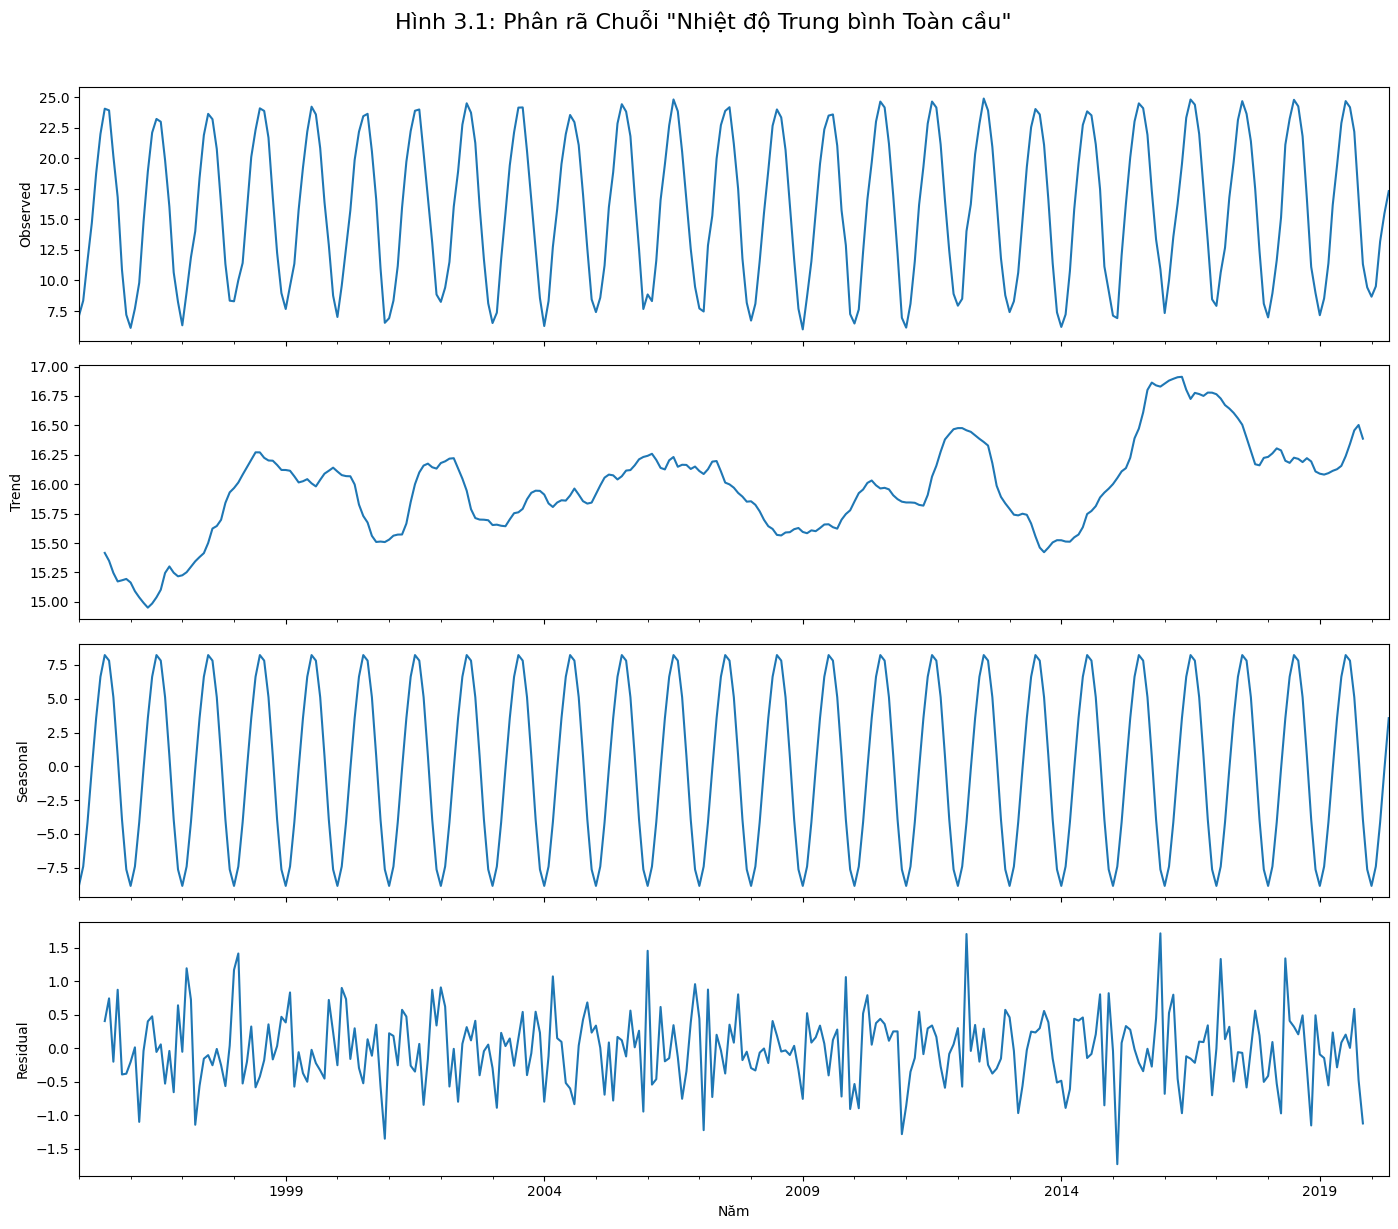

In [30]:
# --- Cell 16: Bắt đầu Chương 3 - Resample và Phân rã Chuỗi 1 ---
import statsmodels.api as sm
import pandas as pd # Đảm bảo pandas đã import
import matplotlib.pyplot as plt

print("--- BẮT ĐẦU CHƯƠNG 3: PHÂN TÍCH CHUỖI THỜI GIAN ---")

# 1. Đảm bảo 2 biến df_global_avg và df_daily_max đã tồn tại (từ Cell 10)
# (Chúng ta chạy lại logic của Cell 10 để chắc chắn)
try:
    _ = df_global_avg.head(1)
    _ = df_daily_max.head(1)
    print("Đã tìm thấy 2 biến 'df_global_avg' và 'df_daily_max'.")
except NameError:
    print("LỖI: Không tìm thấy 2 biến. Đang chạy lại logic Cell 10...")
    # Đảm bảo df tồn tại (từ Cell 9)
    try:
        df_check = df.head(1)
    except NameError:
        print("Lỗi nghiêm trọng: 'df' không tồn tại. Đang tải lại file sạch...")
        # (Giả định bạn đã lưu bằng Parquet ở Cell 8)
        # Nếu bạn lưu bằng CSV, hãy đổi 'read_parquet' thành 'read_csv'
        try:
            df = pd.read_parquet('city_temperatures_clean.parquet')
        except FileNotFoundError:
            df = pd.read_csv('city_temperatures_clean.csv', parse_dates=['Date'])
        
    df_global_avg = df.groupby('Date')['AvgTemperature_C'].mean().reset_index()
    df_daily_max = df.groupby('Date')['AvgTemperature_C'].max().reset_index()
    print("Đã tạo lại 2 biến.")

# 2. Resample (Tổng hợp) theo Tháng ('M')
# Dữ liệu hàng ngày (365) quá nhiễu, phân tích theo tháng (12) sẽ rõ ràng hơn.
# Đặt 'Date' làm index để resample
df_global_avg_indexed = df_global_avg.set_index('Date')
df_global_monthly = df_global_avg_indexed['AvgTemperature_C'].resample('M').mean()

print("Đã resample 'Nhiệt độ trung bình toàn cầu' theo Tháng.")

# 3. Phân rã chuỗi (Mục 3.1)
# Sử dụng mô hình 'additive' (cộng) 
decomposition_global = sm.tsa.seasonal_decompose(df_global_monthly, model='additive')

# 4. Vẽ biểu đồ phân rã
print("\n--- Đang vẽ Biểu đồ Phân rã (Mục 3.1) ---")
# Tạo một khung hình (figure) và 4 trục (axes)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Vẽ 4 biểu đồ thành phần
decomposition_global.observed.plot(ax=ax1, legend=False)
ax1.set_ylabel('Observed')
decomposition_global.trend.plot(ax=ax2, legend=False)
ax2.set_ylabel('Trend')
decomposition_global.seasonal.plot(ax=ax3, legend=False)
ax3.set_ylabel('Seasonal')
decomposition_global.resid.plot(ax=ax4, legend=False)
ax4.set_ylabel('Residual')

# Đặt tiêu đề chung
plt.suptitle('Hình 3.1: Phân rã Chuỗi "Nhiệt độ Trung bình Toàn cầu"', y=1.02, fontsize=16)
plt.xlabel('Năm')
plt.tight_layout() # Tự động căn chỉnh
plt.show() # Hiển thị biểu đồ

--- Đang vẽ Biểu đồ 1: Dữ liệu Quan sát (Observed) ---


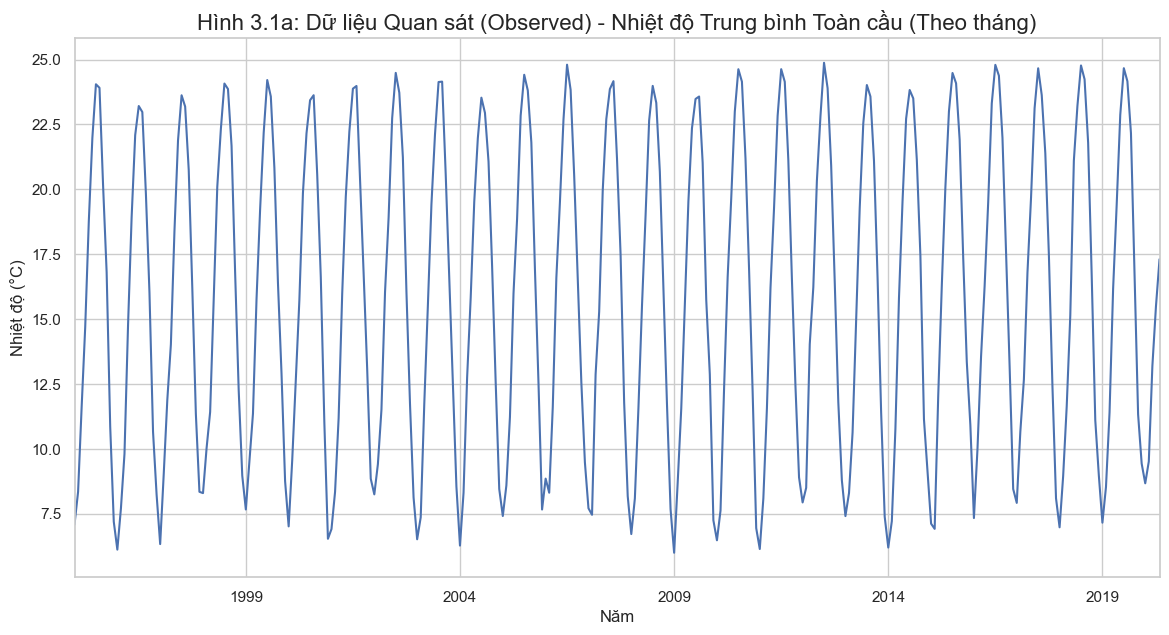

In [ ]:
# --- Cell 17: Biểu đồ Dữ liệu Quan sát (Observed - Mục 3.1) ---
print("--- Đang vẽ Biểu đồ 1: Dữ liệu Quan sát (Observed) ---")

plt.figure(figsize=(14, 7)) # Kich thuoc bieu do

# Ve bieu do du lieu goc (da resample theo thang)
df_global_monthly.plot(legend=False)

plt.title('Hình 3.1a: Dữ liệu Quan sát (Observed) - Nhiệt độ Trung bình Toàn cầu (Theo tháng)', fontsize=16)
plt.ylabel('Nhiệt độ (°C)')
plt.xlabel('Năm')
plt.show() # Hien thi bieu do

--- Đang vẽ Biểu đồ 2: Yếu tố Xu hướng (Trend) ---


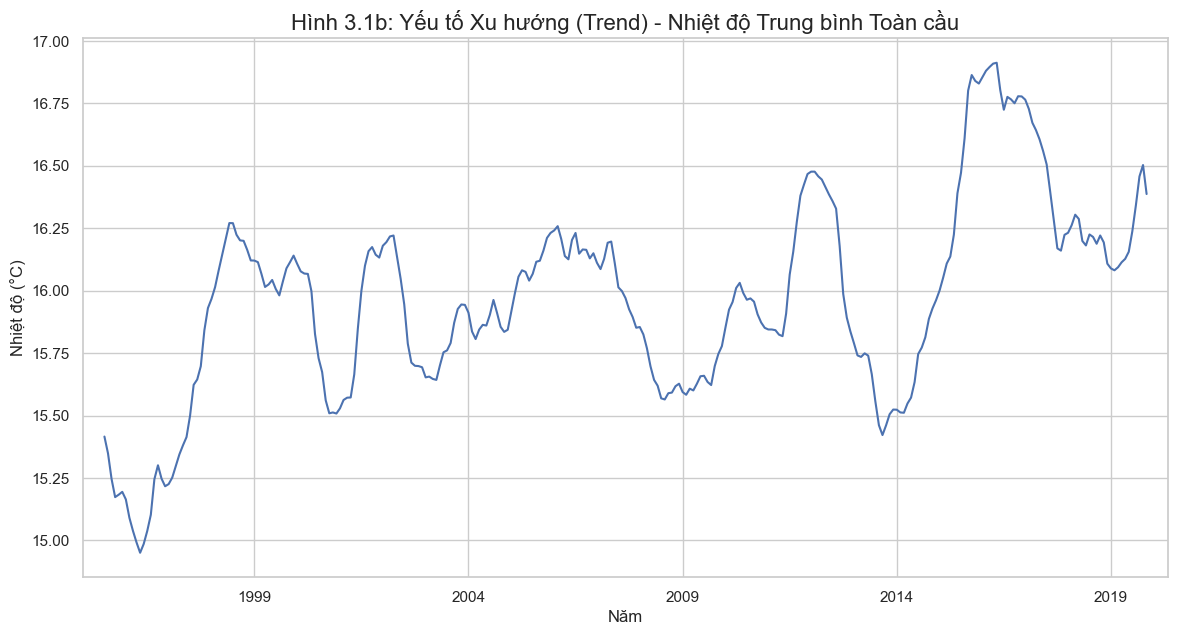

In [ ]:
# --- Cell 18: Biểu đồ Yếu tố Xu hướng (Trend - Mục 3.1.1) ---
print("--- Đang vẽ Biểu đồ 2: Yếu tố Xu hướng (Trend) ---")

plt.figure(figsize=(14, 7))

# Ve thanh phan 'Trend' tu bien 'decomposition_global' (da tao o Cell 16)
decomposition_global.trend.plot(legend=False)

plt.title('Hình 3.1b: Yếu tố Xu hướng (Trend) - Nhiệt độ Trung bình Toàn cầu', fontsize=16)
plt.ylabel('Nhiệt độ (°C)')
plt.xlabel('Năm')
plt.show()

--- Đang vẽ Biểu đồ 3: Yếu tố Mùa vụ (Seasonal) ---


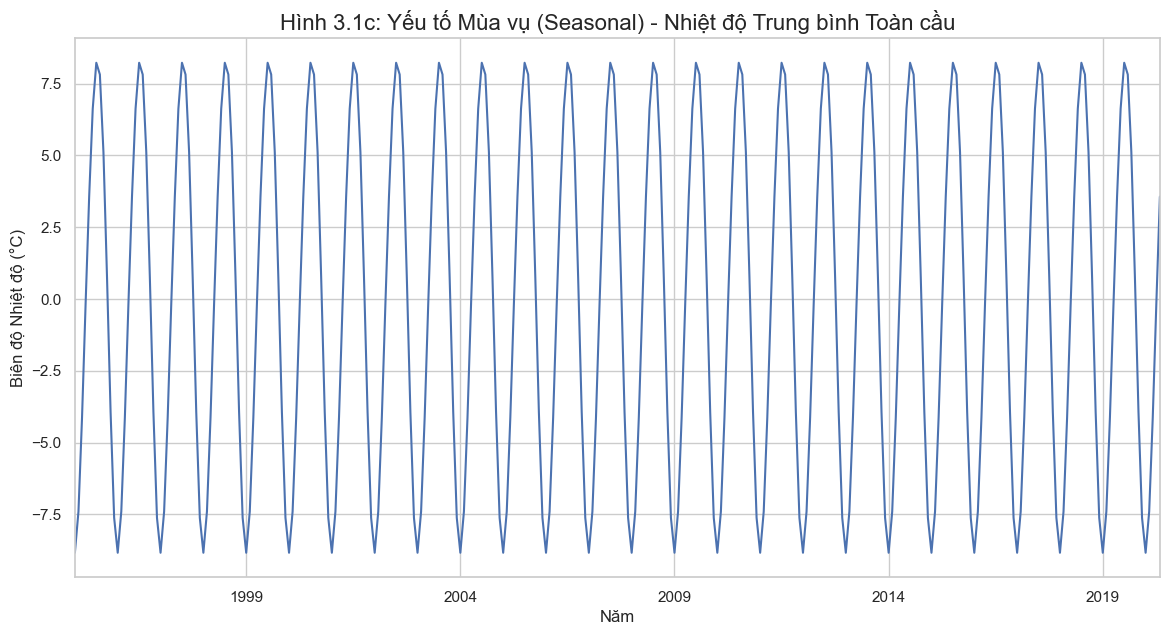

In [ ]:
# --- Cell 19: Biểu đồ Yếu tố Mùa vụ (Seasonal - Mục 3.1.2) ---
print("--- Đang vẽ Biểu đồ 3: Yếu tố Mùa vụ (Seasonal) ---")

plt.figure(figsize=(14, 7))

# Ve thanh phan 'Seasonal'
decomposition_global.seasonal.plot(legend=False)

plt.title('Hình 3.1c: Yếu tố Mùa vụ (Seasonal) - Nhiệt độ Trung bình Toàn cầu', fontsize=16)
plt.ylabel('Biên độ Nhiệt độ (°C)')
plt.xlabel('Năm')
plt.show()

--- Đang vẽ Biểu đồ 4: Thành phần Nhiễu (Residual) ---


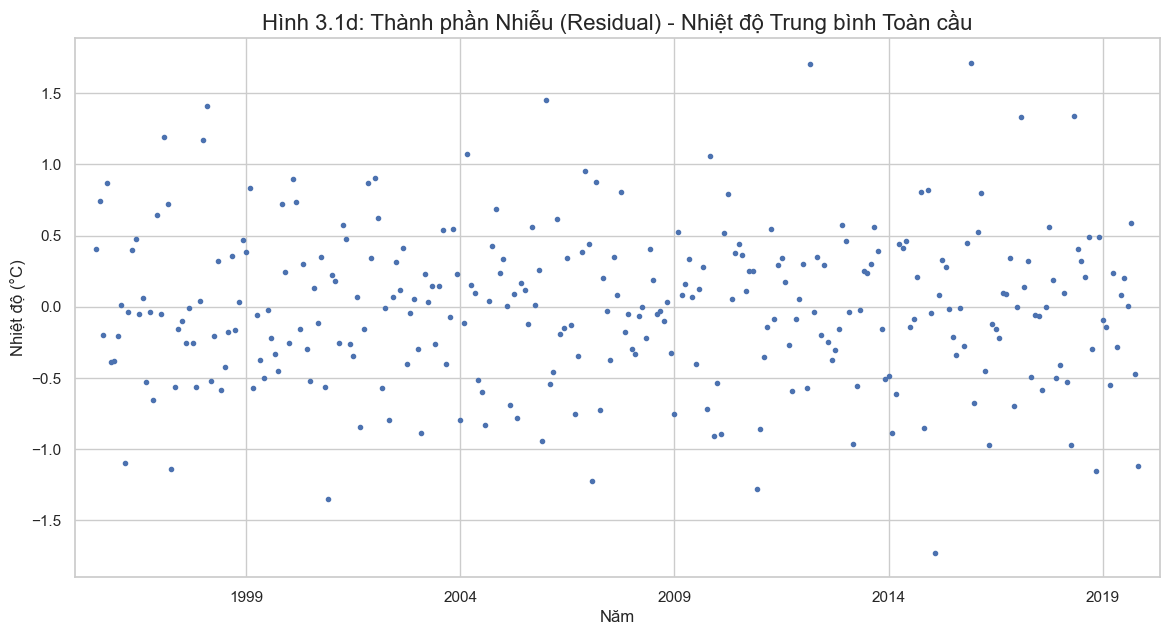

In [ ]:
# --- Cell 20: Biểu đồ Thành phần Nhiễu (Residual - Mục 3.1.3) ---
print("--- Đang vẽ Biểu đồ 4: Thành phần Nhiễu (Residual) ---")

plt.figure(figsize=(14, 7))

# Ve thanh phan 'Resid'
# (Luu y: Bieu do nhieu thuong ro hon khi dung kieu diem '.' thay vi kieu duong 'line')
decomposition_global.resid.plot(linestyle='none', marker='.', legend=False)

plt.title('Hình 3.1d: Thành phần Nhiễu (Residual) - Nhiệt độ Trung bình Toàn cầu', fontsize=16)
plt.ylabel('Nhiệt độ (°C)')
plt.xlabel('Năm')
plt.show()

--- Đang Phân rã Chuỗi 2: 'Nhiệt độ cao nhất mỗi ngày' (Mục 3.2) ---
Đã resample 'Nhiệt độ cao nhất' theo Tháng.

--- Đang vẽ Biểu đồ Phân rã (Mục 3.2) ---


C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\2818656738.py:9: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



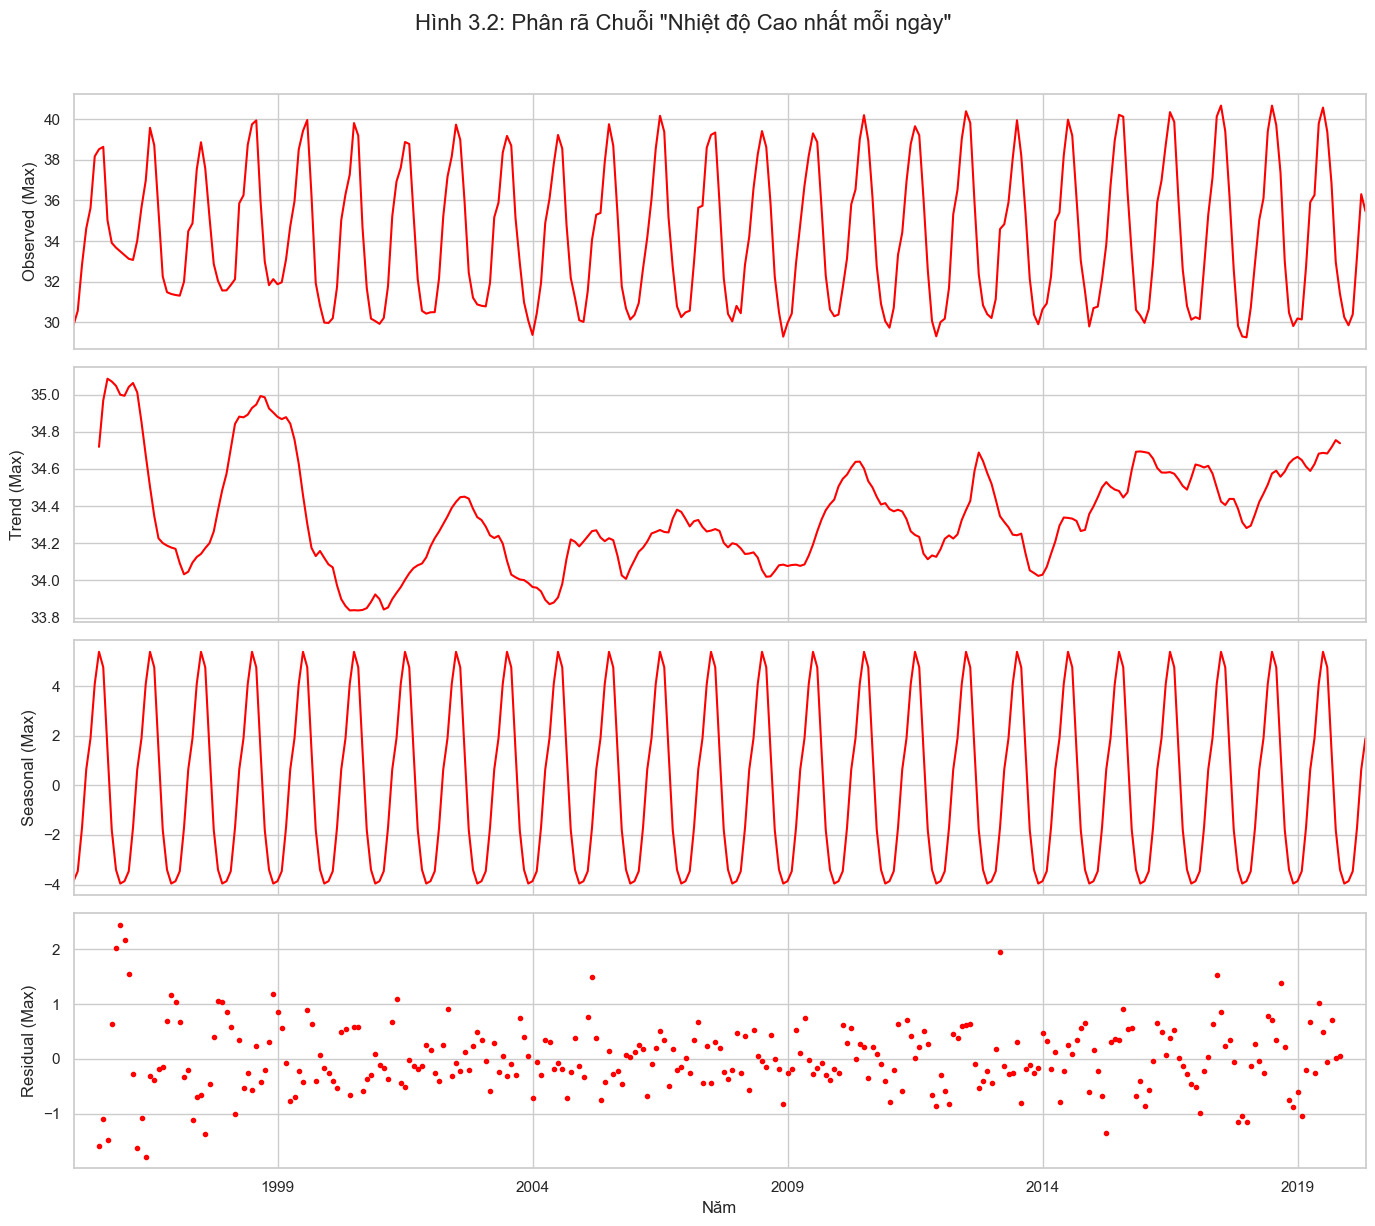

In [ ]:
# --- Cell 21: Thực hiện Mục 3.2 (Phân rã Chuỗi 2: "Nhiệt độ cao nhất") ---
# (Biến 'df_daily_max' đã được tạo ở Cell 10)

print("--- Đang Phân rã Chuỗi 2: 'Nhiệt độ cao nhất mỗi ngày' (Mục 3.2) ---")

# 1. Resample 'Nhiệt độ cao nhất' theo Tháng ('M')
# (Chúng ta cần làm điều này giống như đã làm với chuỗi 'global avg')
df_daily_max_indexed = df_daily_max.set_index('Date')
df_max_monthly = df_daily_max_indexed['AvgTemperature_C'].resample('M').mean()
print("Đã resample 'Nhiệt độ cao nhất' theo Tháng.")

# 2. Phân rã chuỗi
# (Biến 'decomposition_global' đã được tạo ở Cell 16)
decomposition_max = sm.tsa.seasonal_decompose(df_max_monthly, model='additive')

# 3. Vẽ biểu đồ phân rã
print("\n--- Đang vẽ Biểu đồ Phân rã (Mục 3.2) ---")
# Tạo một khung hình (figure) và 4 trục (axes)
fig_max, (ax1_max, ax2_max, ax3_max, ax4_max) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Vẽ 4 biểu đồ thành phần
decomposition_max.observed.plot(ax=ax1_max, legend=False, color='red')
ax1_max.set_ylabel('Observed (Max)')
decomposition_max.trend.plot(ax=ax2_max, legend=False, color='red')
ax2_max.set_ylabel('Trend (Max)')
decomposition_max.seasonal.plot(ax=ax3_max, legend=False, color='red')
ax3_max.set_ylabel('Seasonal (Max)')
decomposition_max.resid.plot(ax=ax4_max, legend=False, linestyle='none', marker='.', color='red')
ax4_max.set_ylabel('Residual (Max)')

plt.suptitle('Hình 3.2: Phân rã Chuỗi "Nhiệt độ Cao nhất mỗi ngày"', y=1.02, fontsize=16)
plt.xlabel('Năm')
plt.tight_layout()
plt.show() # Hiển thị biểu đồ


--- Đang vẽ Biểu đồ so sánh 2 chuỗi (Mục 3.3.1) ---


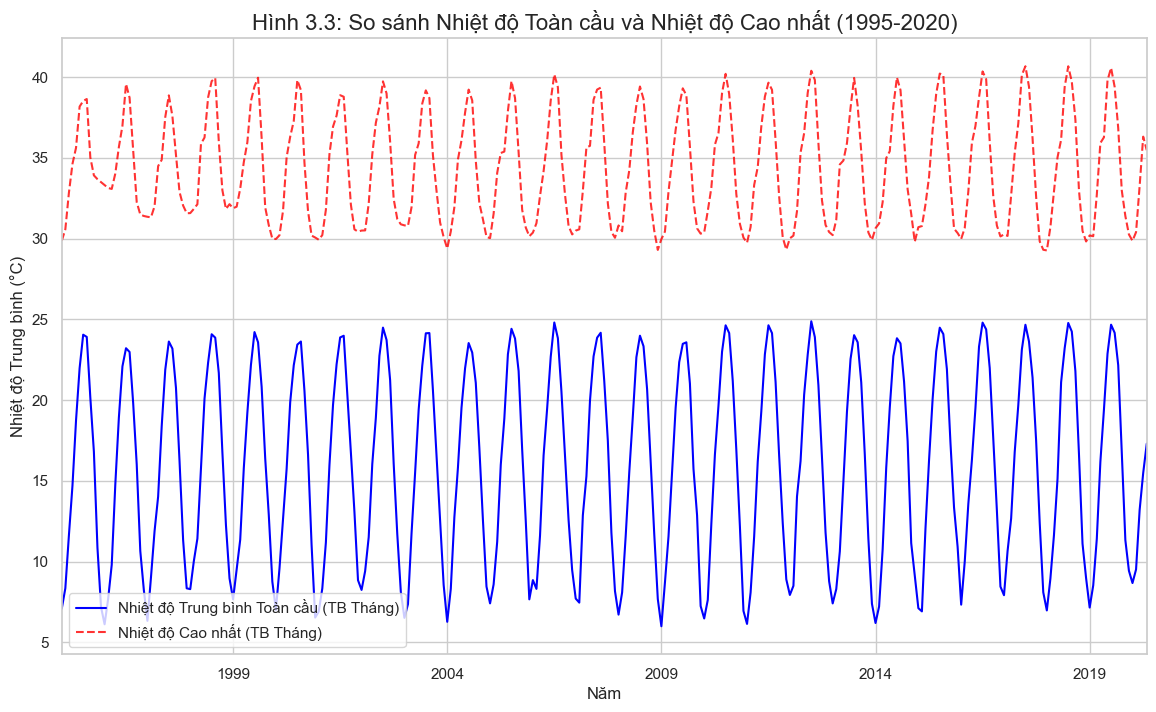

In [ ]:
# --- Cell 22: Thực hiện Mục 3.3.1 (Trực quan hóa so sánh) ---

print("\n--- Đang vẽ Biểu đồ so sánh 2 chuỗi (Mục 3.3.1) ---")

# (Biến 'df_global_monthly' và 'df_max_monthly' đã được tạo ở Cell 16 và 21)
plt.figure(figsize=(14, 8))

# Vẽ chuỗi 1: Trung bình Toàn cầu
df_global_monthly.plot(label='Nhiệt độ Trung bình Toàn cầu (TB Tháng)', legend=True, color='blue')
# Vẽ chuỗi 2: Cao nhất
df_max_monthly.plot(label='Nhiệt độ Cao nhất (TB Tháng)', legend=True, alpha=0.8, linestyle='--', color='red')

plt.title('Hình 3.3: So sánh Nhiệt độ Toàn cầu và Nhiệt độ Cao nhất (1995-2020)', fontsize=16)
plt.ylabel('Nhiệt độ Trung bình (°C)')
plt.xlabel('Năm')
plt.legend()
plt.show() # Hiển thị biểu đồ

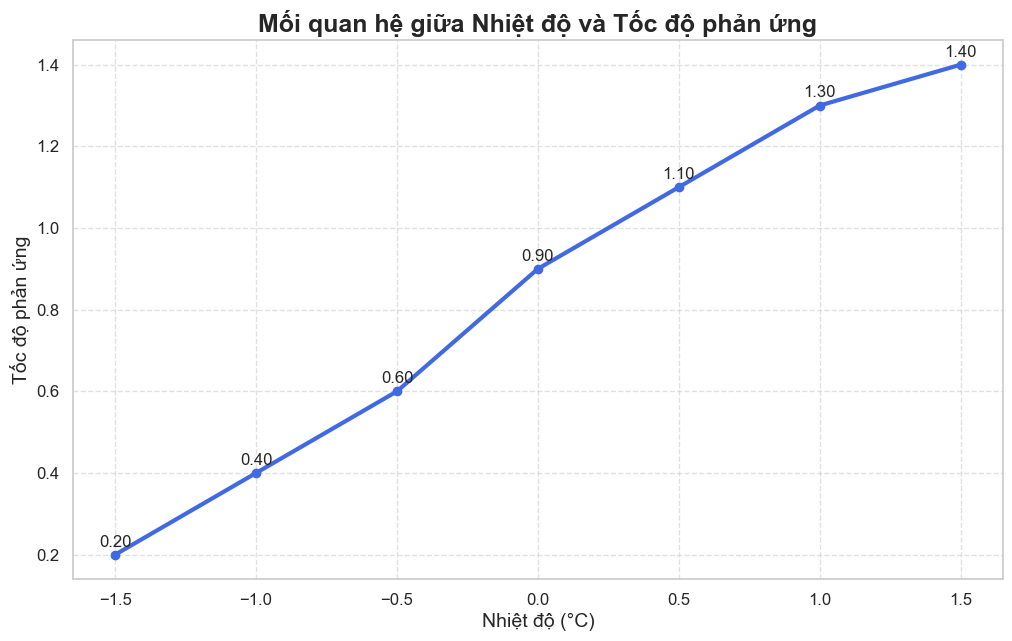

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu mẫu
temperature = np.arange(-1.5, 1.6, 0.5)  # tạo dãy nhiệt độ từ -1.5 đến 1.5, bước 0.5
reaction_rate = [0.2, 0.4, 0.6, 0.9, 1.1, 1.3, 1.4]  # dữ liệu giả định cho tốc độ phản ứng

# Vẽ biểu đồ
plt.figure(figsize=(12, 7))  # tăng kích thước biểu đồ
plt.plot(temperature, reaction_rate, marker='o', color='royalblue', linewidth=3)

# Gắn nhãn và tiêu đề
plt.title("Mối quan hệ giữa Nhiệt độ và Tốc độ phản ứng", fontsize=18, fontweight='bold')
plt.xlabel("Nhiệt độ (°C)", fontsize=14)
plt.ylabel("Tốc độ phản ứng", fontsize=14)
plt.xticks(np.arange(-1.5, 1.6, 0.5), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị giá trị trên từng điểm
for x, y in zip(temperature, reaction_rate):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', fontsize=12)

plt.show()


--- Đang vẽ Biểu đồ so sánh 2 Thành phần Nhiễu (Residuals) ---


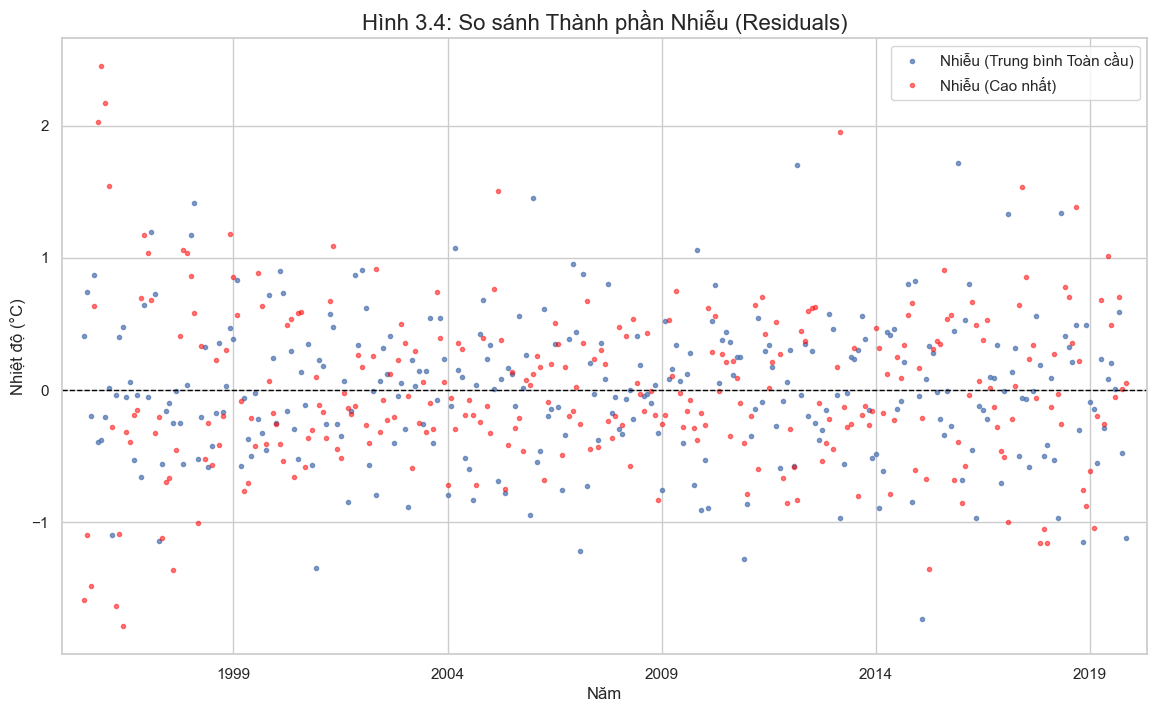

In [ ]:
# --- Cell 23: So sánh Thành phần Nhiễu (Mục 3.3.3) ---

print("--- Đang vẽ Biểu đồ so sánh 2 Thành phần Nhiễu (Residuals) ---")

# Giả định: 
# 1. 'decomposition_global' đã được tạo ở Cell 16
# 2. 'decomposition_max' đã được tạo ở Cell 21
# (Nếu 2 biến này không tồn tại, hãy chạy lại Cell 16 và 21 trước)

try:
    # Tạo khung hình và trục (axes)
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 1. Vẽ Nhiễu của "Trung bình Toàn cầu" (màu xanh)
    decomposition_global.resid.plot(
        ax=ax, 
        linestyle='none', 
        marker='.', 
        alpha=0.7, 
        label='Nhiễu (Trung bình Toàn cầu)'
    )
    
    # 2. Vẽ Nhiễu của "Cao nhất" (màu đỏ)
    decomposition_max.resid.plot(
        ax=ax, 
        linestyle='none', 
        marker='.', 
        alpha=0.5, 
        label='Nhiễu (Cao nhất)',
        color='red'
    )
    
    # Thêm đường số 0 để dễ so sánh
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Tùy chỉnh biểu đồ
    ax.set_title('Hình 3.4: So sánh Thành phần Nhiễu (Residuals)', fontsize=16)
    ax.set_ylabel('Nhiệt độ (°C)')
    ax.set_xlabel('Năm')
    ax.legend()
    plt.show()

except NameError:
    print("LỖI: Không tìm thấy 'decomposition_global' hoặc 'decomposition_max'.")
    print("Vui lòng chạy lại Cell 16 và Cell 21 trước khi chạy cell này.")

In [32]:
# --- Cell 24: BẮT ĐẦU CHƯƠNG 4 - Chuẩn bị Dữ liệu ---
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- BẮT ĐẦU CHƯƠNG 4: MÔ HÌNH DỰ BÁO HOLT-WINTER ---")

# 1. Giả định biến 'df_global_monthly' đã tồn tại (từ Cell 16)
try:
    _ = df_global_monthly.head(1)
    print("Đã tìm thấy dữ liệu 'df_global_monthly' (Trung bình Toàn cầu theo Tháng).")
except NameError:
    print("LỖI: Không tìm thấy 'df_global_monthly'. Vui lòng chạy lại Cell 16.")
    # (Bạn có thể thêm code để chạy lại logic Cell 16 ở đây nếu cần)
import joblib
joblib.dump(df_global_monthly, 'global_temp_series.pkl')
print("--- ĐÃ LƯU FILE global_temp_series.pkl CHO CHƯƠNG 5 ---")
# 2. Chia dữ liệu thành 2 tập: Train (1995-2018) và Test (2019-2020)
# Tập Train: Dùng để huấn luyện mô hình
# Tập Test: Dùng để kiểm tra độ chính xác của mô hình
train_data = df_global_monthly[:'2018']
import joblib
# df_global_monthly là biến chứa dữ liệu toàn cầu
joblib.dump(df_global_monthly, 'global_temp_series.pkl')
print("--- ĐÃ LƯU FILE global_temp_series.pkl CHO CHƯƠNG 5 ---")
# 2. Chia dữ liệu thành 2 tập Train (1995-2018) và Test (2019-2020)
train_data = df_global_monthly[:'2018']
test_data = df_global_monthly['2019':]
print(f"Đã chia dữ liệu: {len(train_data)} tháng (Train) và {len(test_data)} tháng (Test).")

--- BẮT ĐẦU CHƯƠNG 4: MÔ HÌNH DỰ BÁO HOLT-WINTER ---
Đã tìm thấy dữ liệu 'df_global_monthly' (Trung bình Toàn cầu theo Tháng).
--- ĐÃ LƯU FILE global_temp_series.pkl CHO CHƯƠNG 5 ---
--- ĐÃ LƯU FILE global_temp_series.pkl CHO CHƯƠNG 5 ---
Đã chia dữ liệu: 288 tháng (Train) và 17 tháng (Test).


In [ ]:
# --- Cell 23.5 (FIX LỖI DẤU CÁCH): Cài đặt 'scikit-learn' ---
import sys
print(f"--- Đang cài đặt 'scikit-learn' (thư viện sklearn) vào: {sys.executable} ---")

# Dùng !pip để cài đặt, NHƯNG THÊM DẤU NGOẶC KÉP (")
# xung quanh {sys.executable} để xử lý lỗi "dấu cách"
!"{sys.executable}" -m pip install scikit-learn

print("--- Cài đặt 'scikit-learn' hoàn tất! ---")

--- Đang cài đặt 'scikit-learn' (thư viện sklearn) vào: c:\Users\NGUYEN TAN TAI\miniconda3\envs\ptdl_moi\python.exe ---
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 560.1 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.9 MB 560.1 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.9 MB 560.1 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.9 MB 568.6 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/8.9 MB 606.3 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/8.9 MB 606.3 kB/s eta 0:00:1

In [ ]:
# --- Cell 25: Mục 4.2.1 - Mô hình 1 (Hệ số Tiêu chuẩn) ---

print("\n--- Đang huấn luyện Mô hình 1 (Hệ số Tiêu chuẩn) ---")

# 1. Khởi tạo mô hình
# trend='add', seasonal='add', seasonal_periods=12
# (Vì C3 chứng minh Trend và Seasonal là dạng CỘNG, chu kỳ 12 tháng)
model_std = ExponentialSmoothing(
    train_data, 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
)

# 2. Huấn luyện (Fit) mô hình với HỆ SỐ TỰ CHỌN (Tiêu chuẩn)
# (Chúng ta tự chọn alpha, beta, gamma và KHÔNG TỐI ƯU)
fit_std = model_std.fit(
    smoothing_level=0.2,  # alpha
    smoothing_trend=0.1,  # beta
    smoothing_seasonal=0.1, # gamma
    optimized=False # Quan trọng: KHÔNG TỰ TỐI ƯU
)

# 3. Dự báo
# Dự báo số bước bằng đúng độ dài của tập Test (để so sánh)
forecast_std = fit_std.forecast(len(test_data))

print("Huấn luyện Mô hình 1 (Tiêu chuẩn) hoàn tất.")
print(f"Hệ số (Tự chọn): alpha={fit_std.params['smoothing_level']:.2f}, beta={fit_std.params['smoothing_trend']:.2f}, gamma={fit_std.params['smoothing_seasonal']:.2f}")


--- Đang huấn luyện Mô hình 1 (Hệ số Tiêu chuẩn) ---
Huấn luyện Mô hình 1 (Tiêu chuẩn) hoàn tất.
Hệ số (Tự chọn): alpha=0.20, beta=0.10, gamma=0.10


In [7]:
# --- Cell 26: Mục 4.2.2 - Mô hình 2 (Hệ số Tối ưu) ---
from statsmodels.tsa.api import ExponentialSmoothing
import joblib
import pandas as pd

print("\n--- Đang huấn luyện Mô hình 2 (Hệ số Tối ưu) ---")

# ========================================================
# ĐOẠN CODE CỨU CÁNH: TỰ ĐỘNG NẠP LẠI DỮ LIỆU BỊ MẤT
# ========================================================
try:
    # Nạp dữ liệu từ file 'global_temp_series.pkl' bạn đã tạo trước đó
    df_global_monthly = joblib.load('global_temp_series.pkl')
    
    # Tạo lại biến train_data để máy tính hiểu
    train_data = df_global_monthly[:'2018']
    test_data = df_global_monthly['2019':]
    print("✅ Đã khôi phục dữ liệu 'train_data' thành công!")
except FileNotFoundError:
    print("❌ LỖI: Không tìm thấy file 'global_temp_series.pkl'.")
    print("👉 Bạn bắt buộc phải quay lại chạy Cell 24 trước để tạo file này.")

# ========================================================

# 1. Khởi tạo mô hình (giống như trên)
model_opt = ExponentialSmoothing(
    train_data, 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
)

# 2. Huấn luyện (Fit) mô hình và TỰ ĐỘNG TỐI ƯU HÓA
fit_opt = model_opt.fit(optimized=True)

# 3. LƯU VÀ NÉN FILE MÔ HÌNH (QUAN TRỌNG ĐỂ UPLOAD GITHUB)
# Sử dụng compress=9 để nén file nhỏ nhất có thể
joblib.dump(fit_opt, 'model_Global.pkl', compress=9) 

print("--- ĐÃ LƯU VÀ NÉN FILE model_Global.pkl THÀNH CÔNG ---")

# 4. Dự báo (Để kiểm tra)
if 'test_data' in locals():
    forecast_opt = fit_opt.forecast(len(test_data))
    print("Huấn luyện hoàn tất.")
    print(f"Hệ số (Tối ưu): alpha={fit_opt.params['smoothing_level']:.2f}, beta={fit_opt.params['smoothing_trend']:.2f}, gamma={fit_opt.params['smoothing_seasonal']:.2f}")


--- Đang huấn luyện Mô hình 2 (Hệ số Tối ưu) ---
✅ Đã khôi phục dữ liệu 'train_data' thành công!
--- ĐÃ LƯU VÀ NÉN FILE model_Global.pkl THÀNH CÔNG ---
Huấn luyện hoàn tất.
Hệ số (Tối ưu): alpha=0.22, beta=0.00, gamma=0.00


In [ ]:
# --- Cell 27: Mục 4.2.3 - Đánh giá và so sánh hai mô hình ---

print("\n--- Đang tính toán Lỗi Dự báo (RMSE, MAE) ---")

# (FIX LỖI 'squared')
# 1. Tính toán MSE (Mean Squared Error) trước
# (Hàm mean_squared_error mặc định trả về MSE)
mse_std = mean_squared_error(test_data, forecast_std)
mse_opt = mean_squared_error(test_data, forecast_opt)

# 2. Tự lấy căn bậc hai (sqrt) của MSE để ra RMSE
# (Chúng ta dùng 'np' từ 'import numpy as np' ở Cell 24)
rmse_std = np.sqrt(mse_std)
rmse_opt = np.sqrt(mse_opt)

print("Đã tính RMSE thành công (tương thích với phiên bản sklearn cũ).")

# Tính toán MAE (Mean Absolute Error)
mae_std = mean_absolute_error(test_data, forecast_std)
mae_opt = mean_absolute_error(test_data, forecast_opt)

# In kết quả (Đây là Bảng 4.1 của bạn)
print("\n--- Bảng 4.1: So sánh Lỗi Dự báo 2 Mô hình (Nhiệt độ Toàn cầu) ---")
print("| Mô hình | RMSE (Lỗi TB) | MAE (Lỗi Tuyệt đối TB) |")
print("| :--- | :--- | :--- |")
print(f"| 1. Tiêu chuẩn | {rmse_std:.4f} | {mae_std:.4f} |")
print(f"| 2. Tối ưu | {rmse_opt:.4f} | {mae_opt:.4f} |")


--- Đang tính toán Lỗi Dự báo (RMSE, MAE) ---
Đã tính RMSE thành công (tương thích với phiên bản sklearn cũ).

--- Bảng 4.1: So sánh Lỗi Dự báo 2 Mô hình (Nhiệt độ Toàn cầu) ---
| Mô hình | RMSE (Lỗi TB) | MAE (Lỗi Tuyệt đối TB) |
| :--- | :--- | :--- |
| 1. Tiêu chuẩn | 0.9416 | 0.7056 |
| 2. Tối ưu | 0.8742 | 0.6527 |



--- Đang vẽ Biểu đồ So sánh Dự báo (Hình 4.1) ---


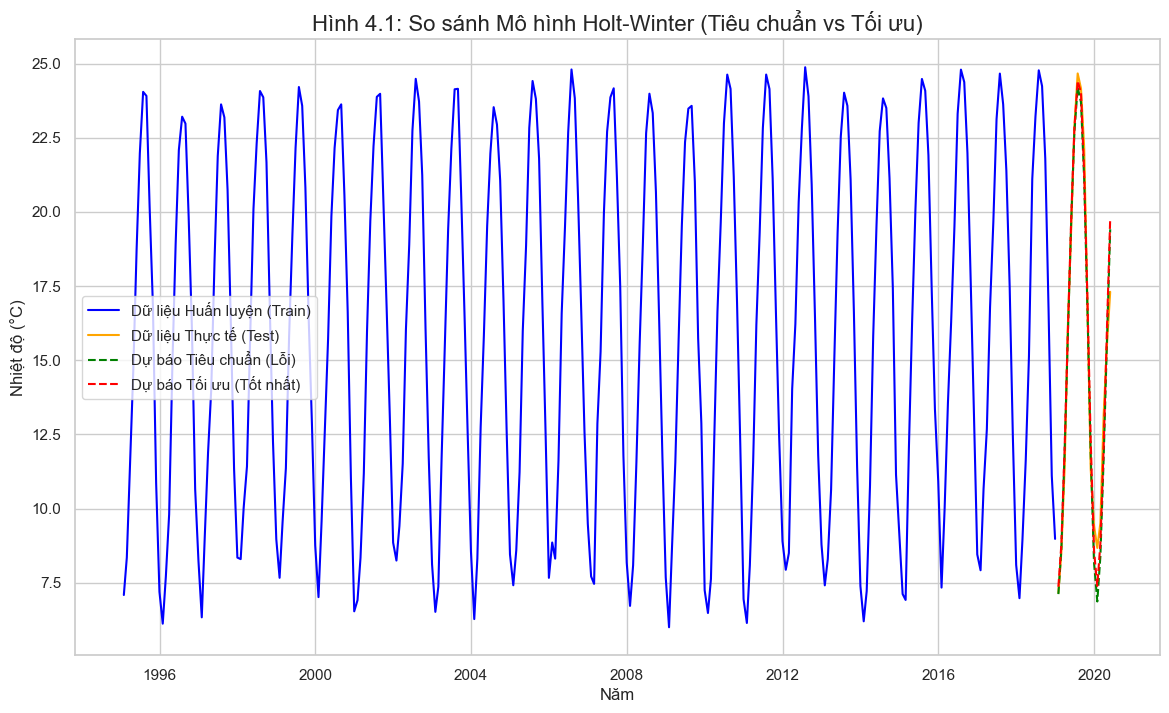

In [ ]:
# --- Cell 28: Mục 4.2.3 - Trực quan hóa So sánh 2 Mô hình ---

print("\n--- Đang vẽ Biểu đồ So sánh Dự báo (Hình 4.1) ---")

plt.figure(figsize=(14, 8))

# Vẽ 4 đường
plt.plot(train_data, label='Dữ liệu Huấn luyện (Train)', color='blue')
plt.plot(test_data, label='Dữ liệu Thực tế (Test)', color='orange')
plt.plot(forecast_std, label='Dự báo Tiêu chuẩn (Lỗi)', linestyle='--', color='green')
plt.plot(forecast_opt, label='Dự báo Tối ưu (Tốt nhất)', linestyle='--', color='red')

# Căn chỉnh biểu đồ
plt.title('Hình 4.1: So sánh Mô hình Holt-Winter (Tiêu chuẩn vs Tối ưu)', fontsize=16)
plt.ylabel('Nhiệt độ (°C)')
plt.xlabel('Năm')
plt.legend()
plt.show() # Hiển thị biểu đồ

In [ ]:
# --- Cell 32: BẮT ĐẦU CHƯƠNG 5 - Huấn luyện và LƯU (Save) Mô hình ---
import pickle
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd

print("--- BẮT ĐẦU CHƯƠNG 5: Huấn luyện và Lưu trữ Mô hình ---")

# 1. Đảm bảo các biến dữ liệu tồn tại (từ các cell trước)
try:
    _ = df_global_monthly.head(1)
    _ = df_5_cities.head(1)
    print("Đã tìm thấy dữ liệu 'df_global_monthly' và 'df_5_cities'.")
except NameError:
    print("LỖI: Không tìm thấy biến. Vui lòng chạy lại Cell 9, 11, và 16.")
    # (Dừng lại nếu thiếu dữ liệu)
    raise

# --- 1. Huấn luyện và Lưu Mô hình "TOÀN CẦU" ---
print("Đang huấn luyện mô hình TOÀN CẦU (Global)...")
model_global = ExponentialSmoothing(
    df_global_monthly, 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12
)
# Huấn luyện trên TOÀN BỘ dữ liệu (1995-2020) để có dự báo tốt nhất
fit_global = model_global.fit(optimized=True)

# Lưu mô hình
with open('model_Global.pkl', 'wb') as f:
    pickle.dump(fit_global, f)
print("Đã lưu 'model_Global.pkl'")


# --- 2. Huấn luyện và Lưu 5 MÔ HÌNH THÀNH PHỐ ---
cities_list = ['Chicago', 'Moscow', 'Paris', 'Singapore', 'Sydney']

for city in cities_list:
    print(f"Đang huấn luyện mô hình cho: {city}...")
    
    # Chuẩn bị dữ liệu (lọc và resample theo tháng cho từng thành phố)
    df_city_data = df_5_cities[df_5_cities['City'] == city].copy()
    df_city_monthly = df_city_data.set_index('Date')['AvgTemperature_C'].resample('M').mean()
    
    # Khởi tạo mô hình
    model_city = ExponentialSmoothing(
        df_city_monthly, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    )
    # Huấn luyện Tối ưu trên TOÀN BỘ dữ liệu (1995-2020)
    fit_city = model_city.fit(optimized=True)
    
    # Lưu mô hình (ví dụ: model_Paris.pkl)
    file_name = f'model_{city}.pkl'
    with open(file_name, 'wb') as f:
        pickle.dump(fit_city, f)
    print(f"Đã lưu '{file_name}'")

print("\n--- HOÀN TẤT LƯU 6 MÔ HÌNH. BẠN ĐÃ SẴN SÀNG TẠO ỨNG DỤNG! ---")

--- BẮT ĐẦU CHƯƠNG 5: Huấn luyện và Lưu trữ Mô hình ---
Đã tìm thấy dữ liệu 'df_global_monthly' và 'df_5_cities'.
Đang huấn luyện mô hình TOÀN CẦU (Global)...
Đã lưu 'model_Global.pkl'
Đang huấn luyện mô hình cho: Chicago...
Đã lưu 'model_Chicago.pkl'
Đang huấn luyện mô hình cho: Moscow...


C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\1151309257.py:43: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\1151309257.py:43: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Đã lưu 'model_Moscow.pkl'
Đang huấn luyện mô hình cho: Paris...
Đã lưu 'model_Paris.pkl'
Đang huấn luyện mô hình cho: Singapore...
Đã lưu 'model_Singapore.pkl'
Đang huấn luyện mô hình cho: Sydney...


C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\1151309257.py:43: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\1151309257.py:43: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\Users\NGUYEN TAN TAI\AppData\Local\Temp\ipykernel_10380\1151309257.py:43: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Đã lưu 'model_Sydney.pkl'

--- HOÀN TẤT LƯU 6 MÔ HÌNH. BẠN ĐÃ SẴN SÀNG TẠO ỨNG DỤNG! ---
